In [38]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

In [39]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#normalizing pixel values between 0 & 1
x_train, x_test = x_train / 255.0, x_test / 255.0

In [40]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [41]:
def create_model(activation):
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation=activation, input_shape=(784,)),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',  # uses gradient descent internally
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [42]:
activations = ['relu', 'sigmoid', 'tanh']
results = {}
histories = {}

for act in activations:
    print(f"\nTraining with {act} activation")

    model = create_model(act)

    history = model.fit(
        x_train, y_train,
        epochs=5,
        validation_split=0.2,
        verbose=0
    )

    train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    histories[act] = history.history
    results[act] = (train_acc, test_acc)


Training with relu activation

Training with sigmoid activation

Training with tanh activation


In [43]:
print("\nFinal Accuracy Comparison:")
for act, (train_acc, test_acc) in results.items():
    print(f"{act.upper()} -> Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")


Final Accuracy Comparison:
RELU -> Train Accuracy: 0.9870, Test Accuracy: 0.9771
SIGMOID -> Train Accuracy: 0.9788, Test Accuracy: 0.9705
TANH -> Train Accuracy: 0.9857, Test Accuracy: 0.9731


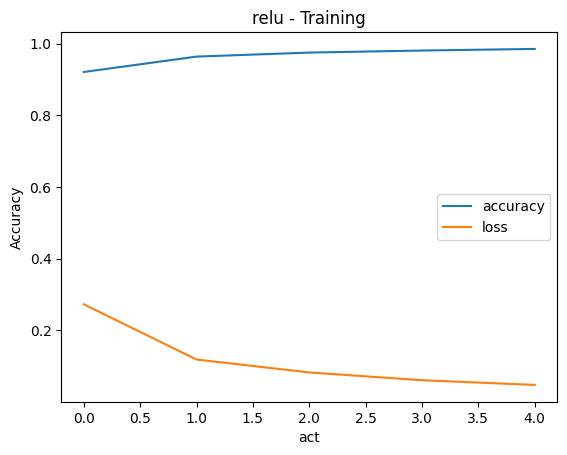

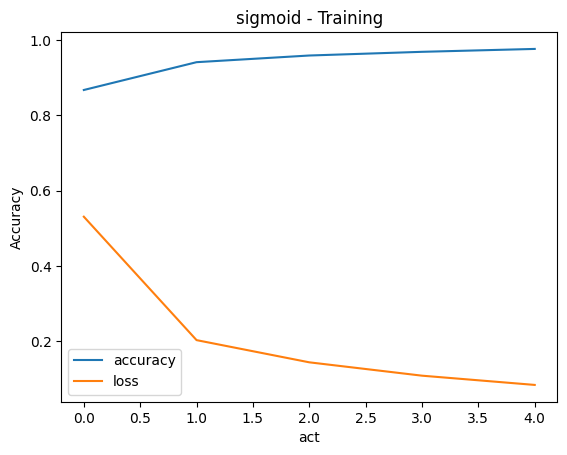

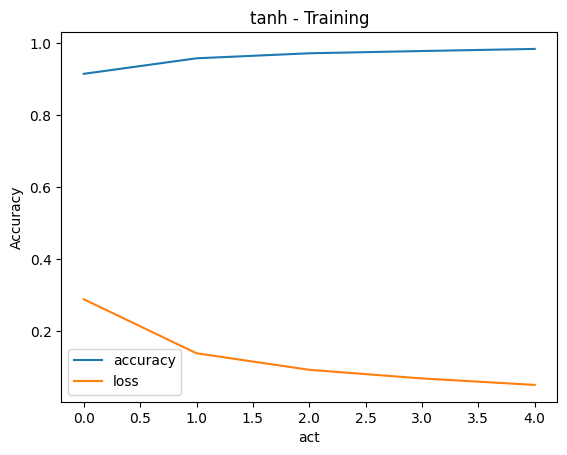

In [52]:
import matplotlib.pyplot as plt

act = ["relu", "sigmoid", "tanh"]

for act in act:
    hist = histories[act]  # dictionary storing histories

    # Accuracy Plot
    plt.figure()
    plt.plot(hist['accuracy'])
    plt.plot(hist['loss'])
    plt.title(f'{act} - Training')
    plt.xlabel('act')
    plt.ylabel('Accuracy')
    plt.legend(['accuracy', 'loss'])
    plt.show()

*optimizers*

In [44]:

# Normalize and reshape
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)



In [48]:
import time 

# Model function
def create_model():
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Optimizers
optimizers = {
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "RMSprop": keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": keras.optimizers.Adam(learning_rate=0.001)
}
res_opt={}

for name, optimizer in optimizers.items():
    print(f"\nTraining with {name}")

    model = create_model()
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start_time = time.time()

    history = model.fit(
        x_train, y_train,
        epochs=5,
        validation_split=0.2,
        verbose=1
    )

    end_time = time.time()

    histories[name] = history.history
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    res_opt[name] = {
        "train_acc": history.history['accuracy'][-1],
        "val_acc": history.history['val_accuracy'][-1],
        "train_loss": history.history['loss'][-1],
        "val_loss": history.history['val_loss'][-1],
        "test_acc": test_acc,
        "training_time": end_time - start_time
    }



Training with SGD
Epoch 1/5


/Users/amishasingh/Documents/DLLab/stable_venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 806us/step - accuracy: 0.1140 - loss: 2.3000 - val_accuracy: 0.1060 - val_loss: 2.3004
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.1140 - loss: 2.2994 - val_accuracy: 0.1060 - val_loss: 2.3002
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 868us/step - accuracy: 0.1140 - loss: 2.2991 - val_accuracy: 0.1060 - val_loss: 2.3002
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 804us/step - accuracy: 0.1140 - loss: 2.2988 - val_accuracy: 0.1060 - val_loss: 2.2993
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 838us/step - accuracy: 0.1140 - loss: 2.2984 - val_accuracy: 0.1060 - val_loss: 2.2990

Training with RMSprop
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5464 - loss: 1.3654 - val_accuracy: 0.7923 - val_loss: 0.6800
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 881us/step - accuracy: 0.8200 - loss: 0.5937 - val_accuracy: 0.8621 - val_loss: 0.4654
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 874us/step - accuracy: 0.866

In [49]:

# Print results
for opt, res in res_opt.items():
    print(f"\nOptimizer: {opt}")
    print(f"Train Accuracy: {res['train_acc']:.4f}")
    print(f"Validation Accuracy: {res['val_acc']:.4f}")
    print(f"Test Accuracy: {res['test_acc']:.4f}")
    print(f"Train Loss: {res['train_loss']:.4f}")
    print(f"Validation Loss: {res['val_loss']:.4f}")
    print(f"Training Time: {res['training_time']:.2f} sec")


Optimizer: SGD
Train Accuracy: 0.1140
Validation Accuracy: 0.1060
Test Accuracy: 0.1135
Train Loss: 2.2984
Validation Loss: 2.2990
Training Time: 6.63 sec

Optimizer: RMSprop
Train Accuracy: 0.8976
Validation Accuracy: 0.9068
Test Accuracy: 0.9038
Train Loss: 0.3537
Validation Loss: 0.3169
Training Time: 7.76 sec

Optimizer: Adam
Train Accuracy: 0.9093
Validation Accuracy: 0.9143
Test Accuracy: 0.9135
Train Loss: 0.3141
Validation Loss: 0.2900
Training Time: 8.45 sec


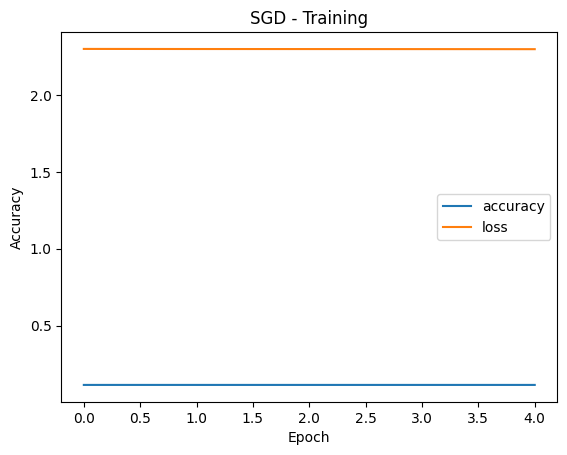

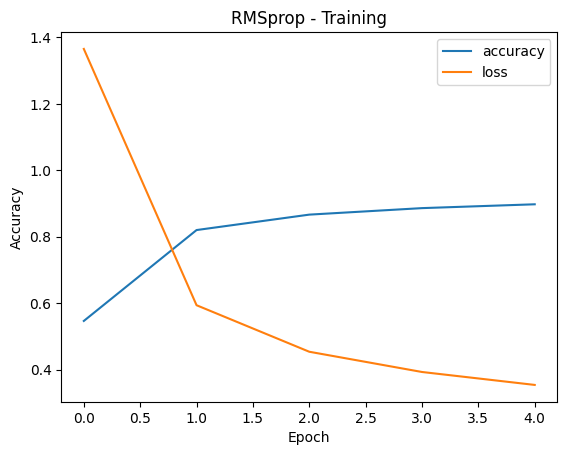

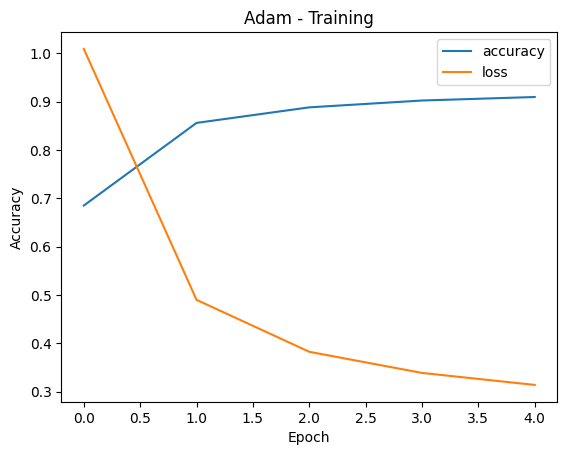

In [ ]:
optimizers = ["SGD", "RMSprop", "Adam"]

for opt in optimizers:
    hist = histories[opt]  # dictionary storing histories

    # Accuracy Plot
    plt.figure()
    plt.plot(hist['accuracy'])
    plt.plot(hist['loss'])
    plt.title(f'{opt} - Training')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['accuracy', 'loss'])
    plt.show()